K Means CLustering - Elvin Roy - 24AR60R37

Step #1 The Following Code Snippet will run Libraries required for Preprocessing 

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

Step #2 Now Let us read the dataset 

In [6]:
url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df = pd.read_csv(url)

Step #3 Preprocessing the Temporal Data

In [9]:
time_analysis = (
    df.query("continent.notna()")  # Exclude continental aggregates
    .pivot_table(index='country', 
                columns='date', 
                values='new_cases_per_million',
                aggfunc='mean')
    .transpose()
    .pipe(lambda x: x.set_axis(pd.to_datetime(x.index), axis=0))
    .resample('ME').mean()      #monthly average
    .fillna(0)
    .transpose()
)


In [11]:
df.to_csv("preprocessed_data", index=False)

Step #4 Importing other libraries too!! 

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Step #5 Normalizing and Clustering the Dataset

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(time_analysis)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

D:\Software_Setup\Python\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Step #6 Creating Cluster Trajectories

In [20]:
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
time_points = pd.date_range(start='2020-03', end='2021-08', freq='ME')


Step #7 Visualisation of the Data

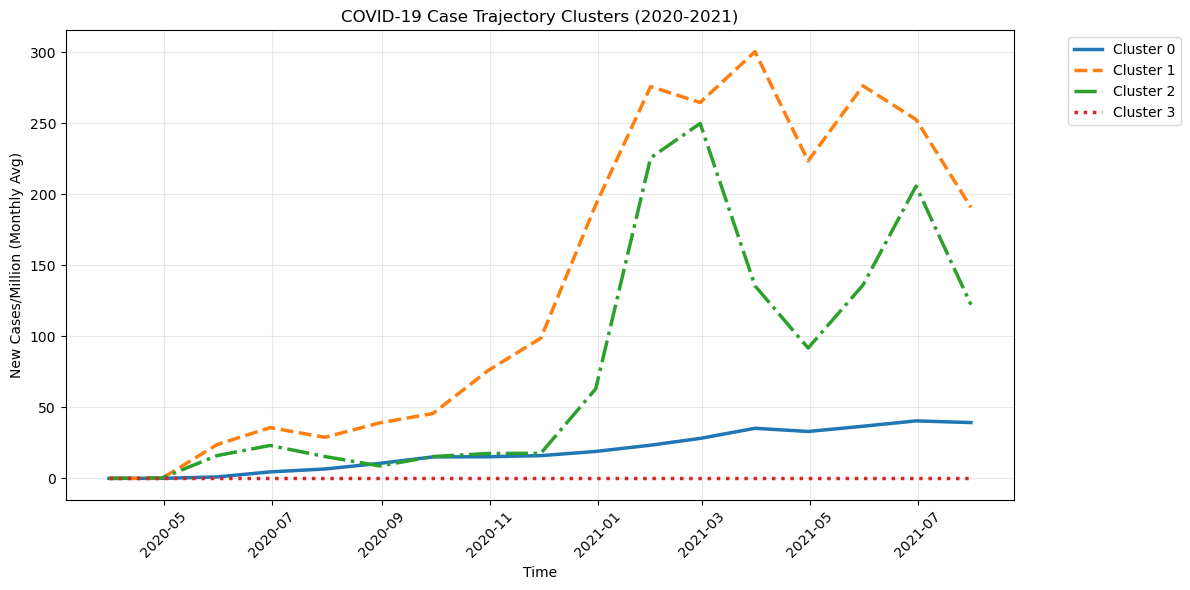

In [25]:
plt.figure(figsize=(12, 6))
for i, center in enumerate(cluster_centers):
    min_len = min(len(time_points), len(center))
    plt.plot(
        time_points[:min_len],
        center[:min_len],
        label=f'Cluster {i}',
        linewidth=2.5,
        linestyle=['-', '--', '-.', ':'][i % 4]
    )

plt.title('COVID-19 Case Trajectory Clusters (2020-2021)')
plt.xlabel('Time')
plt.ylabel('New Cases/Million (Monthly Avg)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Deriving the Silhouette Score

Elbow Method and Silhouette Score check

In [32]:
from sklearn.metrics import silhouette_score
wcss = []
silhouette_scores = []
max_clusters = 10

for k in range(2, max_clusters+1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
    if k > 1:  # Silhouette score requires at least 2 clusters
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))

D:\Software_Setup\Python\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Software_Setup\Python\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Software_Setup\Python\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Software_Setup\Python\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is k

Let us print the result

Text(0.5, 1.0, 'Elbow Method')

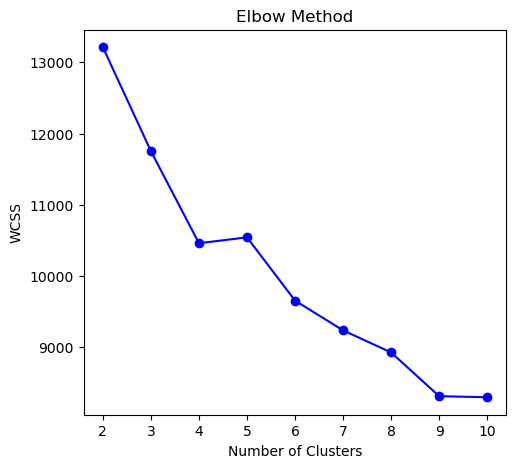

In [34]:
# Plot Elbow Method
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(2, max_clusters+1), wcss, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

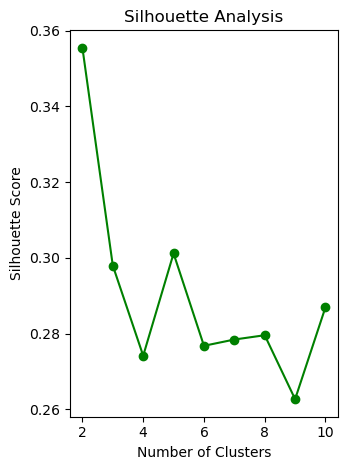

In [36]:
# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(range(2, max_clusters+1), silhouette_scores, 'go-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()